# L'Arène des Algos - Jour 1

**Auteur : Mohammed MOSLEH**

Projet de l'après-midi : monter un pipeline ML complet de bout en bout sur un vrai dataset,
puis faire s'affronter plusieurs algos sur un même classement (l'Arène).

On suit les 8 phases du cours. L'idée n'est pas juste de faire tourner `.fit()`,
mais de comparer les algos et de savoir choisir le bon (et expliquer pourquoi).

## Phase 0 : Mise en route

On importe une bonne fois pour toutes ce dont on a besoin.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Une graine de hasard fixe partout : comme ça mes résultats sont reproductibles.
RANDOM_STATE = 42
print("Setup OK, on est prets.")

Setup OK, on est prets.


## Phase 1 : Charger et explorer

Avant de modeliser quoi que ce soit, on regarde la donnee dans les yeux.
On charge le cancer du sein : 569 patients, 30 mesures, tumeur benigne ou maligne.

Le truc important ici : **est-ce que les classes sont equilibrees ?** Si une classe
ecrasait l'autre (genre 95%), un modele bete qui repond toujours pareil aurait l'air
genial alors qu'il est nul. Donc on veut le voir tout de suite.

In [2]:
def explorer_dataset(loader, noms_classes=None):
    """Charge le dataset et affiche ses caracteristiques de base :
    nombre de lignes, de colonnes, les classes et leur repartition.
    Renvoie X, y pour la suite.
    """
    X, y = loader(return_X_y=True)
    n_lignes, n_colonnes = X.shape
    print(f"Lignes, colonnes : ({n_lignes}, {n_colonnes})")

    classes, comptes = np.unique(y, return_counts=True)
    for c, nb in zip(classes, comptes):
        nom = noms_classes[c] if noms_classes else ""
        pct = 100 * nb / n_lignes
        print(f"Classe {c} {nom}: {nb} cas  ({pct:.1f}%)")
    return X, y

X, y = explorer_dataset(load_breast_cancer, {0: "(maligne) ", 1: "(benigne) "})

Lignes, colonnes : (569, 30)
Classe 0 (maligne) : 212 cas  (37.3%)
Classe 1 (benigne) : 357 cas  (62.7%)


### Checkpoint qualite

Le cours demande de tester la fonction sur 3 situations pour verifier qu'elle ne ment pas.

In [3]:
# Cas normal : deja fait au-dessus, le dataset complet.

# Cas limite : on ne garde qu'une seule classe (y == 0).
# Le decompte doit rester honnete et n'afficher que cette classe.
print("--- Cas limite : une seule classe (y == 0) ---")
X_une, y_une = X[y == 0], y[y == 0]
classes, comptes = np.unique(y_une, return_counts=True)
for c, nb in zip(classes, comptes):
    print(f"Classe {c} : {nb} cas")

# Cas adversarial : la repartition en pourcentage est-elle visible ?
# Oui, on l'affiche deja en %. Si une classe faisait 95%, on le verrait direct.
print("\n--- Cas adversarial : repartition en % ---")
classes, comptes = np.unique(y, return_counts=True)
for c, nb in zip(classes, comptes):
    print(f"Classe {c} : {100 * nb / len(y):.1f}%")

--- Cas limite : une seule classe (y == 0) ---
Classe 0 : 212 cas

--- Cas adversarial : repartition en % ---
Classe 0 : 37.3%
Classe 1 : 62.7%


## Phase 2 : Le pipeline supervise complet

On reprend les 5 etapes du matin : charger, separer, entrainer, predire, mesurer.
On encapsule l'entrainement dans une fonction qui prend un modele en argument :
comme ca on pourra brancher n'importe quel algo dessus.

In [4]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    """Entraine le modele, predit sur le test, renvoie l'accuracy (un float entre 0 et 1)."""
    modele.fit(X_train, y_train)          # le modele apprend
    y_pred = modele.predict(X_test)       # il repond sur des donnees jamais vues
    return accuracy_score(y_test, y_pred) # proportion de bonnes reponses

# On separe apprentissage et test. stratify=y garde les memes proportions de
# classes des deux cotes, pour que la comparaison soit juste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

acc = entrainer_et_evaluer(DecisionTreeClassifier(random_state=RANDOM_STATE),
                           X_train, X_test, y_train, y_test)
print(f"Accuracy de l'arbre de decision : {acc:.2%}")

Accuracy de l'arbre de decision : 91.23%


## Phase 3 : L'Arene (premier classement)

On fait s'affronter au moins 3 algos sur le **meme** decoupage train/test
(sinon la comparaison ne veut rien dire). On affiche un classement trie par accuracy.

In [5]:
def arene(modeles, X_train, X_test, y_train, y_test):
    """Entraine plusieurs modeles et renvoie un classement trie par accuracy decroissante."""
    resultats = []
    for nom, modele in modeles.items():
        acc = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        resultats.append((nom, acc))
    resultats.sort(key=lambda x: x[1], reverse=True)  # le meilleur en premier

    for rang, (nom, acc) in enumerate(resultats, start=1):
        print(f"{rang}. {nom:<24}: {acc:.1%}")
    return resultats

modeles = {
    "Regression logistique": LogisticRegression(max_iter=200),
    "KNN":                   KNeighborsClassifier(n_neighbors=3),
    "Arbre de decision":     DecisionTreeClassifier(random_state=RANDOM_STATE),
}
classement_cancer = arene(modeles, X_train, X_test, y_train, y_test)

C:\Users\mosle\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1. Regression logistique   : 96.5%
2. KNN                     : 93.0%
3. Arbre de decision       : 91.2%


### Ce qui doit casser

La regression logistique peut rouspeter avec un avertissement de **non-convergence**.
Pourquoi ? Parce que ses donnees ne sont pas mises a l'echelle : les colonnes ont des
ordres de grandeur tres differents, et l'algo a du mal a converger dans le nombre
d'iterations donne. Voyons l'effet de `max_iter`.

In [6]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# max_iter petit : on force le probleme a apparaitre.
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    try:
        LogisticRegression(max_iter=50).fit(X_train, y_train)
        print("max_iter=50  : a converge")
    except ConvergenceWarning:
        print("max_iter=50  : NON convergence (l'algo n'a pas eu le temps de finir)")

# Avec plus d'iterations, ca passe (mais c'est un pansement : le vrai remede c'est le scaling, Phase 7).
LogisticRegression(max_iter=5000).fit(X_train, y_train)
print("max_iter=5000: a converge")
print("\nNote : augmenter max_iter aide, mais le vrai souci est l'echelle des donnees -> on le prouve en Phase 7.")

max_iter=50  : NON convergence (l'algo n'a pas eu le temps de finir)


max_iter=5000: a converge

Note : augmenter max_iter aide, mais le vrai souci est l'echelle des donnees -> on le prouve en Phase 7.


## Phase 4 : Bascule non-supervise

Maintenant on cache les etiquettes. Un KMeans doit trouver 2 groupes tout seul,
sans jamais voir `y`. Ensuite on compare : est-ce que les groupes trouves
correspondent aux vraies classes benigne/maligne ?

In [7]:
def clustering_aveugle(X, n_clusters=2):
    """Regroupe les donnees en n_clusters sans les etiquettes.
    fit_predict fait l'entrainement ET la prediction d'un coup.
    """
    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    return km.fit_predict(X)

clusters = clustering_aveugle(X, 2)

# Les numeros de cluster (0/1) sont arbitraires : KMeans peut appeler "0" ce que
# nous on appelle "1". On teste donc l'accord dans les deux sens et on garde le meilleur.
accord = max(np.mean(clusters == y), np.mean(clusters == 1 - y))
print(f"Les clusters retrouvent les vraies classes a {accord:.1%}")
print("\nA discuter : un cluster qui retrouve a peu pres les vraies classes,")
print("chance ou vraie structure dans la donnee ? Ici l'accord est eleve,")
print("donc la separation benin/malin est bien presente dans les mesures elles-memes.")

Les clusters retrouvent les vraies classes a 85.4%

A discuter : un cluster qui retrouve a peu pres les vraies classes,
chance ou vraie structure dans la donnee ? Ici l'accord est eleve,
donc la separation benin/malin est bien presente dans les mesures elles-memes.


## Phase 5 : Changer de terrain

On rejoue toute l'Arene, mais sur un autre dataset : `load_wine` (3 classes, donc
du multi-classe, et 13 mesures). Le but : montrer que nos fonctions encaissent un
nouveau dataset **sans etre reecrites** (c'est tout l'interet de l'API uniforme).

In [8]:
print("=== Exploration du vin ===")
Xw, yw = explorer_dataset(load_wine, {0: "(classe 0) ", 1: "(classe 1) ", 2: "(classe 2) "})

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.2, random_state=RANDOM_STATE, stratify=yw
)

print("\n=== Arene sur le vin (3 classes) ===")
modeles_wine = {
    "Regression logistique": LogisticRegression(max_iter=5000),
    "KNN":                   KNeighborsClassifier(n_neighbors=3),
    "Arbre de decision":     DecisionTreeClassifier(random_state=RANDOM_STATE),
}
classement_wine = arene(modeles_wine, Xw_train, Xw_test, yw_train, yw_test)

print("\nA noter : le podium n'est pas le meme que sur le cancer du sein.")
print("Un algo qui gagnait la-bas peut passer derriere ici -> aucun algo n'est roi partout.")

=== Exploration du vin ===
Lignes, colonnes : (178, 13)
Classe 0 (classe 0) : 59 cas  (33.1%)
Classe 1 (classe 1) : 71 cas  (39.9%)
Classe 2 (classe 2) : 48 cas  (27.0%)

=== Arene sur le vin (3 classes) ===


1. Regression logistique   : 94.4%
2. Arbre de decision       : 94.4%
3. KNN                     : 75.0%

A noter : le podium n'est pas le meme que sur le cancer du sein.
Un algo qui gagnait la-bas peut passer derriere ici -> aucun algo n'est roi partout.


## Phase 6 : Voir pour comprendre

Un classement de chiffres c'est bien, un graphique c'est mieux pour decider.
On trace les accuracies en barres, puis la **matrice de confusion** du champion :
elle montre non seulement combien d'erreurs, mais lesquelles.

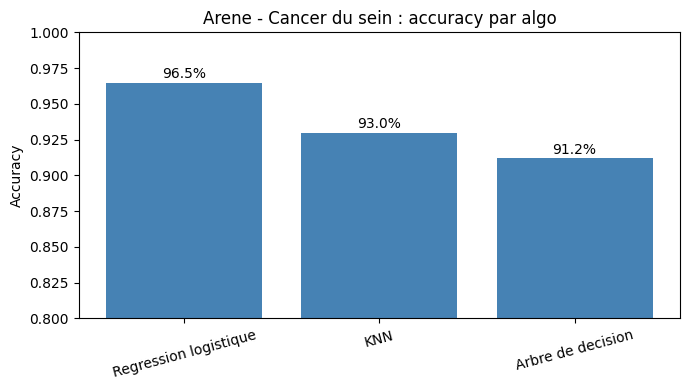

In [9]:
# Diagramme en barres des accuracies (sur le cancer du sein)
noms = [n for n, _ in classement_cancer]
accs = [a for _, a in classement_cancer]

plt.figure(figsize=(7, 4))
plt.bar(noms, accs, color="steelblue")
plt.ylim(0.8, 1.0)
plt.title("Arene - Cancer du sein : accuracy par algo")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
for i, a in enumerate(accs):
    plt.text(i, a + 0.003, f"{a:.1%}", ha="center")
plt.tight_layout()
plt.show()

Champion : Regression logistique
Matrice de confusion (lignes = vrai, colonnes = predit) :
            predit malin  predit benin
vrai malin         39             3
vrai benin          1            71


C:\Users\mosle\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


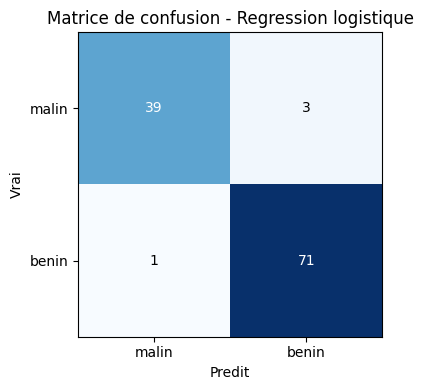


Ce qui est grave ici : rater une tumeur MALIGNE (la dire benigne) est bien
plus dangereux que d'alerter a tort sur une benigne. On regarde donc surtout
la case 'vrai malin / predit benin' -> ce sont les erreurs qui peuvent couter cher.


In [10]:
# Matrice de confusion du champion (le 1er du classement)
champion_nom = classement_cancer[0][0]
champion = modeles[champion_nom]
champion.fit(X_train, y_train)
y_pred = champion.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print(f"Champion : {champion_nom}")
print("Matrice de confusion (lignes = vrai, colonnes = predit) :")
print("            predit malin  predit benin")
print(f"vrai malin       {cm[0,0]:>4}          {cm[0,1]:>4}")
print(f"vrai benin       {cm[1,0]:>4}          {cm[1,1]:>4}")

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Matrice de confusion - {champion_nom}")
plt.xticks([0, 1], ["malin", "benin"]); plt.yticks([0, 1], ["malin", "benin"])
plt.xlabel("Predit"); plt.ylabel("Vrai")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

print("\nCe qui est grave ici : rater une tumeur MALIGNE (la dire benigne) est bien")
print("plus dangereux que d'alerter a tort sur une benigne. On regarde donc surtout")
print("la case 'vrai malin / predit benin' -> ce sont les erreurs qui peuvent couter cher.")

## Phase 7 : Le buff scaling (et la triche qui se retourne contre vous)

### Manche 1 : le buff

On met les donnees a l'echelle avec un `StandardScaler` (chaque colonne ramenee a
moyenne 0, ecart-type 1) et on relance l'Arene. Pour chaque algo on mesure le **gain**
= accuracy scalee moins accuracy brute. C'est le classement des gains qui nous interesse.

In [11]:
def comparer_scaling(modeles, X_train, X_test, y_train, y_test):
    """Pour chaque algo : accuracy SANS puis AVEC scaling, trie par gain decroissant."""
    resultats = []
    for nom, modele in modeles.items():
        # 1) brut
        from sklearn.base import clone
        brut = entrainer_et_evaluer(clone(modele), X_train, X_test, y_train, y_test)

        # 2) scaling : on ajuste le scaler sur le TRAIN seul, puis on transforme les deux
        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)
        scale = entrainer_et_evaluer(clone(modele), X_train_s, X_test_s, y_train, y_test)

        resultats.append((nom, brut, scale, scale - brut))

    resultats.sort(key=lambda r: r[3], reverse=True)
    print(f"{'Algo':<24} {'Brut':>7} {'Scale':>7} {'Gain':>7}")
    for nom, brut, scale, gain in resultats:
        print(f"{nom:<24} {brut:>6.1%} {scale:>7.1%} {gain:>+6.1%}")
    return resultats

modeles_p7 = {
    "Regression logistique": LogisticRegression(max_iter=5000),
    "KNN":                   KNeighborsClassifier(n_neighbors=3),
    "Arbre de decision":     DecisionTreeClassifier(random_state=RANDOM_STATE),
}
res_scaling = comparer_scaling(modeles_p7, X_train, X_test, y_train, y_test)

print("\nIntuition : KNN et regression logistique raisonnent par distances / poids,")
print("ils adorent le scaling. L'arbre decoupe par seuils colonne par colonne,")
print("il se fiche de l'echelle -> gain ~0. Ca colle bien.")

Algo                        Brut   Scale    Gain
KNN                       93.0%   98.2%  +5.3%
Regression logistique     96.5%   98.2%  +1.8%
Arbre de decision         91.2%   91.2%  +0.0%

Intuition : KNN et regression logistique raisonnent par distances / poids,
ils adorent le scaling. L'arbre decoupe par seuils colonne par colonne,
il se fiche de l'echelle -> gain ~0. Ca colle bien.


### Manche 2 : la triche (data leakage)

Maintenant on triche **expres** : on ajuste le scaler sur le dataset COMPLET (tout `X`,
avant le split), puis on splitte et on relance le champion. Le souci : le scaler a
« regarde » les donnees de test pour calculer sa moyenne et son ecart-type. Le modele
profite d'une info qu'il n'aurait jamais en vrai. L'accuracy monte... mais elle ment.

In [12]:
from sklearn.base import clone
champ_modele = LogisticRegression(max_iter=5000)

# Version HONNETE : scaler ajuste sur le train seul
scaler_ok = StandardScaler().fit(X_train)
acc_honnete = entrainer_et_evaluer(
    clone(champ_modele),
    scaler_ok.transform(X_train), scaler_ok.transform(X_test),
    y_train, y_test
)

# Version TRICHE : scaler ajuste sur tout X (avant split) -> fuite de donnees
scaler_triche = StandardScaler().fit(X)        # <-- le scaler voit le test
X_all_s = scaler_triche.transform(X)
Xtr_s, Xte_s, ytr, yte = train_test_split(
    X_all_s, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
acc_triche = entrainer_et_evaluer(clone(champ_modele), Xtr_s, Xte_s, ytr, yte)

print(f"Accuracy honnete (scaler sur train) : {acc_honnete:.2%}")
print(f"Accuracy en trichant (scaler sur tout): {acc_triche:.2%}")
print(f"Mensonge gagne en trichant            : {acc_triche - acc_honnete:+.2%}")
print("\nReflexe a graver : on ajuste TOUJOURS le scaler sur le train seul.")
print("Ici le delta est peut-etre minuscule, mais sur d'autres datasets il transforme")
print("un modele moyen en faux champion qui s'effondre le jour du deploiement.")
print("make_pipeline(StandardScaler(), modele) rend cette triche impossible par accident.")

Accuracy honnete (scaler sur train) : 98.25%
Accuracy en trichant (scaler sur tout): 98.25%
Mensonge gagne en trichant            : +0.00%

Reflexe a graver : on ajuste TOUJOURS le scaler sur le train seul.
Ici le delta est peut-etre minuscule, mais sur d'autres datasets il transforme
un modele moyen en faux champion qui s'effondre le jour du deploiement.
make_pipeline(StandardScaler(), modele) rend cette triche impossible par accident.


## Phase 8 : Raconter votre Arene (synthese)

Le detail complet est dans le **README**. En resume :

- **Le probleme** : classification supervisee (tumeur benigne/maligne, puis vin a 3 classes).
- **Les algos compares** : regression logistique, KNN, arbre de decision.
- **Champion retenu** : la **regression logistique** (une fois les donnees mises a l'echelle).
  - Tres bonne accuracy, **rapide**, et surtout **explicable** : on peut dire quelles mesures
    pesent dans la decision. En sante (comme en banque/assurance), l'explicabilite compte
    autant que la performance.
  - Sur le cancer du sein, le type d'erreur qui fait peur c'est de rater une tumeur maligne :
    on choisit donc un modele qu'on peut analyser, pas une boite noire.
- **Lecon scaling** : certains algos (KNN, regression log.) gagnent beaucoup au scaling,
  l'arbre s'en fiche. Et on ajuste le scaler **sur le train seul** pour eviter la fuite de donnees.

> Le meilleur score n'est pas toujours le meilleur modele en vrai : explicabilite,
> type d'erreurs et vitesse comptent autant que l'accuracy.

---
### Recap

On a monte un pipeline complet (charger, separer, entrainer, predire, mesurer),
fait s'affronter 3 algos sur 2 datasets, teste le non-supervise, visualise les resultats,
et prouve chiffres en main pourquoi on met les donnees a l'echelle et pourquoi on ne
laisse jamais le scaler regarder le test. Premiere piece du portfolio, faite !